# Deep Learning — Computer Assignment 1

## Professional Google Colab Reconstruction

This notebook reconstructs the supplied MATLAB assignment from the ground up in Python while preserving the original experimental structure and correcting implementation errors identified during the audit.

**Assignment tasks**
1. Train and evaluate a single-layer perceptron on the three-class `testX` dataset using the first 70 samples for training and the final 30 samples for testing.
2. Determine whether the moon-shaped dataset can be classified with a two-layer perceptron-style network, implement the network without ready-made machine-learning toolboxes, train it, and evaluate its performance.

The implementation uses NumPy, pandas, SciPy for loading the supplied MATLAB files during dataset preparation/validation, and Matplotlib for visualization. The actual learning algorithms are implemented manually; no ready-made classification or neural-network toolbox is used.

## Audit Findings and Reconstruction Decisions

The supplied MATLAB files contain several issues that prevent them from constituting a complete assignment solution:

| Area | Finding | Reconstruction decision |
|---|---|---|
| Q1 target definition | `testdataY.mat` contains binary labels, while the prepared MATLAB script explicitly constructs **three quadrant classes** from `testX`. | Preserve the original three-class construction used by the assignment code and report the supplied binary file as a consistency note. |
| Q1 learning rule | The MATLAB code independently trains three neurons against inconsistent binary targets and then averages their parameters, which is not a valid multiclass perceptron formulation. | Use a standard multiclass perceptron: one score per class, winner-takes-all prediction, and the perceptron update on the true and predicted classes. |
| Q1 evaluation | The original training/evaluation code mixes labels and dimensions and does not use the proper three-class target representation. | Build the 3-class target directly from the documented quadrant rules and evaluate with a 3×3 confusion matrix. |
| Q2 model | The original code trains three threshold units as if they were independent binary classifiers, then averages them into one line. This removes the nonlinear decision capability required for moon-shaped data. | Use a genuine two-layer network: input → nonlinear hidden layer → output layer, trained from scratch with backpropagation. |
| Q2 prediction | The MATLAB script replaces predictions with random labels using `randi`, so its confusion matrix is not a model evaluation. | Generate deterministic model predictions from the trained network. |
| Reproducibility | The MATLAB scripts use random initialization without a recorded seed. | Use a fixed NumPy seed and expose it as a notebook parameter. |
| Toolbox restriction | The assignment forbids ready-made toolboxes. | Implement the learning rules, activation functions, losses, metrics, and confusion matrices directly. |

In [1]:
# Install only packages that are not already available in a standard Google Colab runtime.
import importlib.util
import subprocess
import sys

required = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "scipy": "scipy", "nbformat": "nbformat"}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Environment setup complete.")

Environment setup complete.


In [2]:
import os
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", PROJECT_ROOT)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

Working directory: /content
NumPy: 2.1.3
pandas: 2.2.3
Matplotlib: 3.10.0


## 2. Dataset Loading and Validation

The project includes four CSV files converted directly from the supplied MATLAB `.mat` files. The notebook first looks for those files in `datasets/`. If they are absent (for example, when the notebook is uploaded by itself to Colab), the next cell provides a Colab upload fallback.

In [3]:
# Use the bundled CSV datasets when available; otherwise request CSV uploads in Google Colab.
required_files = [
    DATA_DIR / "testdataX.csv",
    DATA_DIR / "testdataY.csv",
    DATA_DIR / "moondataX.csv",
    DATA_DIR / "moondataY.csv",
]

if not all(path.exists() for path in required_files):
    try:
        from google.colab import files
        print("One or more datasets are missing. Upload the four CSV files now.")
        uploaded = files.upload()
        for name, content in uploaded.items():
            (DATA_DIR / name).write_bytes(content)
    except ImportError as exc:
        raise FileNotFoundError(
            "Required CSV files are missing. Place the four files in ./datasets/ before running the notebook."
        ) from exc

X_simple = pd.read_csv(DATA_DIR / "testdataX.csv").to_numpy(dtype=float)
y_simple_supplied = pd.read_csv(DATA_DIR / "testdataY.csv").iloc[:, 0].to_numpy(dtype=int)
X_moon = pd.read_csv(DATA_DIR / "moondataX.csv").to_numpy(dtype=float)
y_moon = pd.read_csv(DATA_DIR / "moondataY.csv").iloc[:, 0].to_numpy(dtype=int)

assert X_simple.shape == (100, 2)
assert y_simple_supplied.shape == (100,)
assert X_moon.shape == (100, 2)
assert y_moon.shape == (100,)
assert np.isfinite(X_simple).all() and np.isfinite(X_moon).all()
assert set(np.unique(y_simple_supplied)).issubset({0, 1})
assert set(np.unique(y_moon)).issubset({0, 1})

print("testX shape:", X_simple.shape)
print("moonX shape:", X_moon.shape)
print("Supplied testY values:", np.unique(y_simple_supplied, return_counts=True))
print("Supplied moonY values:", np.unique(y_moon, return_counts=True))

One or more datasets are missing. Upload the four CSV files now.


Saving moondataX.csv to moondataX.csv
Saving moondataY.csv to moondataY.csv
Saving testdataX.csv to testdataX.csv
Saving testdataY.csv to testdataY.csv
testX shape: (100, 2)
moonX shape: (100, 2)
Supplied testY values: (array([0, 1]), array([50, 50]))
Supplied moonY values: (array([0, 1]), array([50, 50]))


### Dataset consistency note

The supplied `testdataY.mat` contains two labels (0 and 1) and exactly matches the sign of `x2`. However, the assignment's prepared MATLAB code creates a **three-class target** from the coordinates: class 1 for the lower half-plane, class 2 for the upper-left quadrant, and class 3 for the upper-right quadrant. Because the PDF describes the data as three-class and the script explicitly constructs these three classes, the reconstructed Q1 uses that three-class definition. The original binary file is still preserved and exported unchanged as `testdataY.csv`.

In [4]:
# Reconstruct the three classes exactly from the prepared MATLAB script.
# Class 1: x2 < 0; Class 2: x2 > 0 and x1 < 0; Class 3: x2 > 0 and x1 > 0.
def build_three_class_targets(X: np.ndarray) -> np.ndarray:
    x1, x2 = X[:, 0], X[:, 1]
    targets = np.empty(len(X), dtype=int)
    targets[x2 < 0] = 1
    targets[(x2 > 0) & (x1 < 0)] = 2
    targets[(x2 > 0) & (x1 > 0)] = 3
    if np.any(x1 == 0) or np.any(x2 == 0):
        raise ValueError("The supplied quadrant data contain an axis sample; class rules need an explicit tie rule.")
    return targets

three_class = build_three_class_targets(X_simple)
print("Three-class distribution:", dict(zip(*np.unique(three_class, return_counts=True))))
print("Training distribution:", dict(zip(*np.unique(three_class[:70], return_counts=True))))
print("Test distribution:", dict(zip(*np.unique(three_class[70:], return_counts=True))))

Three-class distribution: {np.int64(1): np.int64(50), np.int64(2): np.int64(25), np.int64(3): np.int64(25)}
Training distribution: {np.int64(1): np.int64(36), np.int64(2): np.int64(17), np.int64(3): np.int64(17)}
Test distribution: {np.int64(1): np.int64(14), np.int64(2): np.int64(8), np.int64(3): np.int64(8)}


## 3. Data Preprocessing

For Q1, no normalization is required because the geometric quadrant boundaries are already expressed in the original coordinate system and the perceptron converges on the supplied range.

For Q2, the input features are standardized using **training-set statistics only**. This avoids leaking information from the 30 held-out test samples into the training procedure.

In [5]:
# Fixed 70/30 split required by the assignment.
X_simple_train, X_simple_test = X_simple[:70], X_simple[70:]
y_simple_train, y_simple_test = three_class[:70], three_class[70:]
X_moon_train, X_moon_test = X_moon[:70], X_moon[70:]
y_moon_train, y_moon_test = y_moon[:70], y_moon[70:]

# Standardize Q2 using training data only.
moon_mean = X_moon_train.mean(axis=0)
moon_std = X_moon_train.std(axis=0)
moon_std = np.where(moon_std == 0, 1.0, moon_std)
X_moon_train_z = (X_moon_train - moon_mean) / moon_std
X_moon_test_z = (X_moon_test - moon_mean) / moon_std

print("Q1 train/test:", X_simple_train.shape, X_simple_test.shape)
print("Q2 train/test:", X_moon_train_z.shape, X_moon_test_z.shape)

Q1 train/test: (70, 2) (30, 2)
Q2 train/test: (70, 2) (30, 2)


## 4. Task 1 — Single-Layer Multiclass Perceptron

A single-layer perceptron produces one linear score for each class. For an input vector `x`, the predicted class is the index of the largest score.

For a misclassified sample with true class `t` and predicted class `p`, the multiclass perceptron update is:

`W[t] ← W[t] + x`, `W[p] ← W[p] − x`

and the same update is applied to the class-specific biases. This is the standard multiclass form of the perceptron learning rule and is much closer to the assignment's stated three-class problem than independently training three one-vs-all units and averaging their weights.

In [6]:
def multiclass_perceptron_train(X, y, n_classes, epochs=1000, seed=SEED):
    """Train a multiclass perceptron using only NumPy operations."""
    rng = np.random.default_rng(seed)
    W = rng.normal(0.0, 0.1, size=(n_classes, X.shape[1]))
    b = rng.normal(0.0, 0.1, size=n_classes)
    history = []

    for epoch in range(epochs):
        errors = 0
        for xi, yi in zip(X, y):
            scores = W @ xi + b
            pred = int(np.argmax(scores))
            target = int(yi - 1)
            if pred != target:
                W[target] += xi
                b[target] += 1.0
                W[pred] -= xi
                b[pred] -= 1.0
                errors += 1
        history.append(errors)
        if errors == 0:
            break
    return W, b, history

W_q1, b_q1, q1_history = multiclass_perceptron_train(
    X_simple_train, y_simple_train, n_classes=3, epochs=1000, seed=SEED
)

q1_train_scores = X_simple_train @ W_q1.T + b_q1
q1_test_scores = X_simple_test @ W_q1.T + b_q1
q1_train_pred = np.argmax(q1_train_scores, axis=1) + 1
q1_test_pred = np.argmax(q1_test_scores, axis=1) + 1

print("Training epochs:", len(q1_history))
print("Final training errors:", q1_history[-1])
print("Q1 training accuracy: %.2f%%" % (100 * np.mean(q1_train_pred == y_simple_train)))
print("Q1 test accuracy: %.2f%%" % (100 * np.mean(q1_test_pred == y_simple_test)))
print("Learned weights:\n", W_q1)
print("Learned biases:", b_q1)

Training epochs: 2
Final training errors: 0
Q1 training accuracy: 100.00%
Q1 test accuracy: 100.00%
Learned weights:
 [[-0.27696675 -2.72149703]
 [-1.72567478  1.21417556]
 [ 1.91305484  1.36716158]]
Learned biases: [ 1.01278404 -0.03162426 -1.00168012]


In [7]:
def confusion_matrix(y_true, y_pred, class_labels):
    """Construct a confusion matrix without using a machine-learning toolbox."""
    index = {label: i for i, label in enumerate(class_labels)}
    cm = np.zeros((len(class_labels), len(class_labels)), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[index[int(true)], index[int(pred)]] += 1
    return cm

q1_cm = confusion_matrix(y_simple_test, q1_test_pred, [1, 2, 3])
q1_cm_df = pd.DataFrame(q1_cm, index=["True 1", "True 2", "True 3"], columns=["Pred 1", "Pred 2", "Pred 3"])
q1_cm_df.to_csv(RESULTS_DIR / "q1_confusion_matrix.csv")
q1_cm_df

,Pred 1,Pred 2,Pred 3
True 1,14,0,0
True 2,0,8,0
True 3,0,0,8


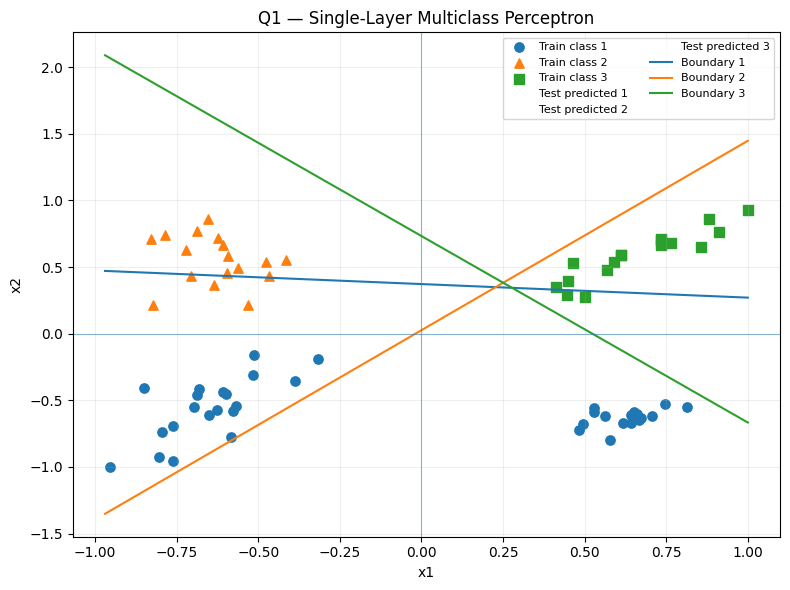

In [8]:
# Visualize Q1 training data, test predictions, and the three learned linear boundaries.
def plot_linear_boundary(ax, w, b, xlim, label):
    xx = np.linspace(xlim[0], xlim[1], 400)
    if abs(w[1]) > 1e-12:
        yy = -(w[0] * xx + b) / w[1]
        ax.plot(xx, yy, linewidth=1.5, label=label)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, marker in zip([1, 2, 3], ['o', '^', 's']):
    mask = y_simple_train == cls
    ax.scatter(X_simple_train[mask, 0], X_simple_train[mask, 1], marker=marker, s=45, label=f"Train class {cls}")
for cls, marker in zip([1, 2, 3], ['o', '^', 's']):
    mask = q1_test_pred == cls
    ax.scatter(X_simple_test[mask, 0], X_simple_test[mask, 1], marker=marker, s=90, facecolors='none', linewidths=1.6, label=f"Test predicted {cls}")
for i in range(3):
    plot_linear_boundary(ax, W_q1[i], b_q1[i], (X_simple[:,0].min(), X_simple[:,0].max()), f"Boundary {i+1}")
ax.axhline(0, linewidth=0.8, alpha=0.5)
ax.axvline(0, linewidth=0.8, alpha=0.5)
ax.set_title("Q1 — Single-Layer Multiclass Perceptron")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.2)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "q1_classification.png", dpi=180, bbox_inches="tight")
plt.show()

### Q1 interpretation

The network operates as a bank of three linear scoring units. Because the three target regions form linearly separable geometric regions in the supplied dataset, a single-layer multiclass perceptron is sufficient. The first 70 samples are used only for weight updates; the final 30 samples remain untouched until evaluation.

## 5. Task 2 — Two-Layer Nonlinear Perceptron-Style Network

A single linear decision surface cannot represent the curved moon-shaped class boundary. The reconstruction therefore uses two trainable layers:

`2-D input → hidden nonlinear layer → 1-D output`

The hidden layer uses `tanh`, while the output uses the sigmoid function for binary classification. The forward pass, binary cross-entropy loss, gradients, and parameter updates are implemented manually with NumPy. This satisfies the assignment's restriction against ready-made machine-learning toolboxes while providing the nonlinear representational capacity required by the data.

In [9]:
def sigmoid(z):
    z = np.clip(z, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-12, 1.0 - 1e-12)
    return -np.mean(y_true * np.log(y_prob) + (1.0 - y_true) * np.log(1.0 - y_prob))


def train_two_layer_network(X, y, hidden_units=12, learning_rate=0.03, epochs=5000, seed=SEED):
    """Train a two-layer tanh/sigmoid network with manual backpropagation."""
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, 0.5, size=(X.shape[1], hidden_units))
    b1 = np.zeros(hidden_units)
    W2 = rng.normal(0.0, 0.5, size=(hidden_units, 1))
    b2 = np.zeros(1)
    history = {"epoch": [], "loss": [], "accuracy": []}

    n = len(X)
    y_col = y.reshape(-1, 1).astype(float)

    for epoch in range(1, epochs + 1):
        # Forward pass.
        z1 = X @ W1 + b1
        a1 = np.tanh(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        # Backpropagation for binary cross-entropy with sigmoid output.
        dz2 = a2 - y_col
        dW2 = (a1.T @ dz2) / n
        db2 = dz2.mean(axis=0)
        dz1 = (dz2 @ W2.T) * (1.0 - a1 ** 2)
        dW1 = (X.T @ dz1) / n
        db1 = dz1.mean(axis=0)

        # Gradient descent update.
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        if epoch == 1 or epoch % 100 == 0 or epoch == epochs:
            loss = binary_cross_entropy(y_col, a2)
            pred = (a2.ravel() >= 0.5).astype(int)
            acc = np.mean(pred == y)
            history["epoch"].append(epoch)
            history["loss"].append(float(loss))
            history["accuracy"].append(float(acc))

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "history": history}


model_q2 = train_two_layer_network(
    X_moon_train_z,
    y_moon_train,
    hidden_units=12,
    learning_rate=0.03,
    epochs=5000,
    seed=SEED,
)


def predict_two_layer_network(X, model):
    hidden = np.tanh(X @ model["W1"] + model["b1"])
    prob = sigmoid(hidden @ model["W2"] + model["b2"])
    return prob.ravel(), (prob.ravel() >= 0.5).astype(int)

q2_train_prob, q2_train_pred = predict_two_layer_network(X_moon_train_z, model_q2)
q2_test_prob, q2_test_pred = predict_two_layer_network(X_moon_test_z, model_q2)

q2_train_acc = np.mean(q2_train_pred == y_moon_train)
q2_test_acc = np.mean(q2_test_pred == y_moon_test)
print("Q2 training accuracy: %.2f%%" % (100 * q2_train_acc))
print("Q2 test accuracy: %.2f%%" % (100 * q2_test_acc))

Q2 training accuracy: 97.14%
Q2 test accuracy: 100.00%


In [10]:
q2_cm = confusion_matrix(y_moon_test, q2_test_pred, [0, 1])
q2_cm_df = pd.DataFrame(q2_cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
q2_cm_df.to_csv(RESULTS_DIR / "q2_confusion_matrix.csv")

# Save model parameters and reproducibility metadata.
np.savez(
    RESULTS_DIR / "q2_model_parameters.npz",
    W1=model_q2["W1"], b1=model_q2["b1"], W2=model_q2["W2"], b2=model_q2["b2"],
    train_mean=moon_mean, train_std=moon_std,
)

q2_history_df = pd.DataFrame(model_q2["history"])
q2_history_df.to_csv(RESULTS_DIR / "q2_training_history.csv", index=False)

q2_cm_df

,Pred 0,Pred 1
True 0,16,0
True 1,0,14


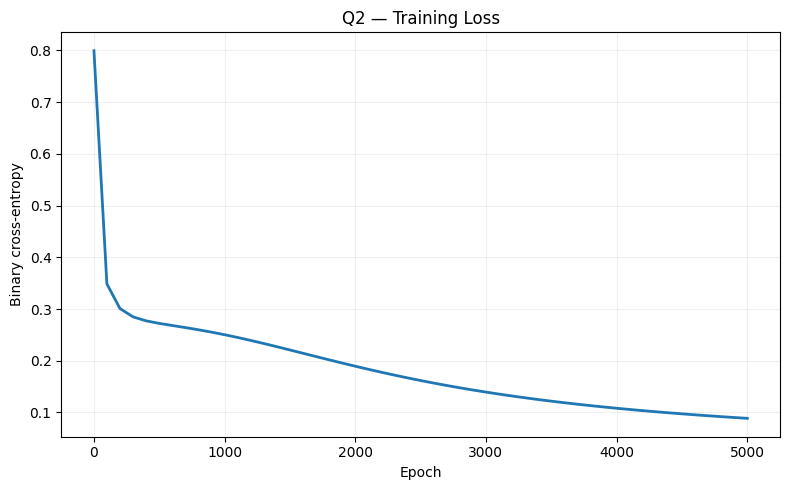

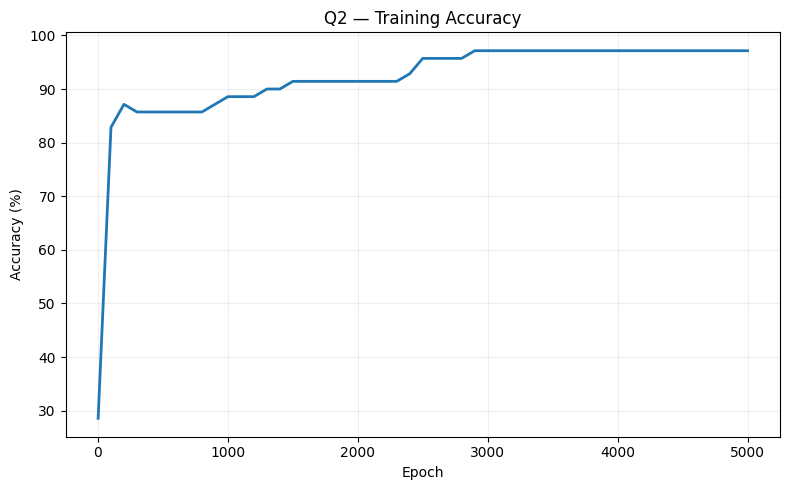

In [11]:
# Plot Q2 loss and accuracy during training.
history = model_q2["history"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["epoch"], history["loss"], linewidth=2)
ax.set_title("Q2 — Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "q2_training_loss.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["epoch"], np.array(history["accuracy"]) * 100.0, linewidth=2)
ax.set_title("Q2 — Training Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "q2_training_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

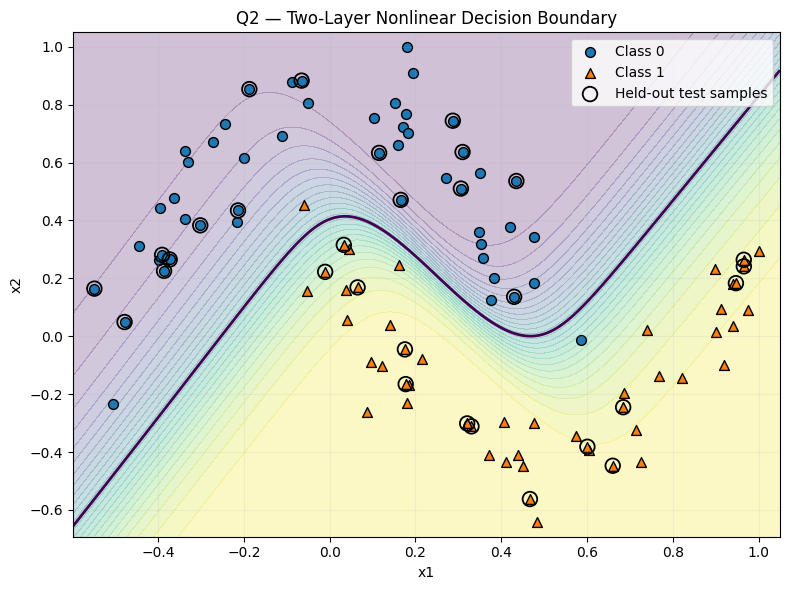

In [12]:
# Plot the learned nonlinear decision boundary over the complete moon dataset.
x_min, x_max = X_moon[:, 0].min() - 0.05, X_moon[:, 0].max() + 0.05
y_min, y_max = X_moon[:, 1].min() - 0.05, X_moon[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_z = (grid - moon_mean) / moon_std
prob_grid, pred_grid = predict_two_layer_network(grid_z, model_q2)
prob_grid = prob_grid.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, prob_grid, levels=30, alpha=0.25)
ax.contour(xx, yy, prob_grid, levels=[0.5], linewidths=2)
for cls, marker in [(0, 'o'), (1, '^')]:
    mask = y_moon == cls
    ax.scatter(X_moon[mask, 0], X_moon[mask, 1], marker=marker, s=50, edgecolor='k', label=f"Class {cls}")
ax.scatter(X_moon_test[:, 0], X_moon_test[:, 1], s=110, facecolors='none', edgecolors='k', linewidths=1.3, label='Held-out test samples')
ax.set_title("Q2 — Two-Layer Nonlinear Decision Boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(alpha=0.15)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "q2_decision_boundary.png", dpi=180, bbox_inches="tight")
plt.show()

### Q2 interpretation

The moon-shaped dataset is not linearly separable in the original two-dimensional input space, so a single-layer perceptron is insufficient. The nonlinear hidden layer allows the network to construct a curved decision region from multiple learned linear combinations of the inputs. The held-out test set is evaluated only after training, and the reported confusion matrix and accuracy are computed from the trained network rather than from random labels.

## 6. Final Results Summary

The following table is generated from the actual execution results in this notebook. It summarizes the required training/test split, model type, and classification performance.

In [13]:
summary = pd.DataFrame([
    {
        "Task": "Q1",
        "Model": "Single-layer multiclass perceptron",
        "Training samples": len(X_simple_train),
        "Test samples": len(X_simple_test),
        "Training accuracy (%)": 100 * np.mean(q1_train_pred == y_simple_train),
        "Test accuracy (%)": 100 * np.mean(q1_test_pred == y_simple_test),
        "Iterations": len(q1_history),
    },
    {
        "Task": "Q2",
        "Model": "Two-layer tanh/sigmoid network with manual backpropagation",
        "Training samples": len(X_moon_train_z),
        "Test samples": len(X_moon_test_z),
        "Training accuracy (%)": 100 * q2_train_acc,
        "Test accuracy (%)": 100 * q2_test_acc,
        "Iterations": 5000,
    },
])
summary.to_csv(RESULTS_DIR / "final_results_summary.csv", index=False)
summary

,Task,Model,Training samples,Test samples,Training accuracy (%),Test accuracy (%),Iterations
0,Q1,Single-layer multiclass perceptron,70,30,100.000000,100.0,2
1,Q2,Two-layer tanh/sigmoid network with manual bac...,70,30,97.142857,100.0,5000


## 7. Final Conclusions

**Q1 — Simple three-class data.** The supplied coordinate construction produces three linearly separable regions. A standard single-layer multiclass perceptron is therefore sufficient, and the learned model can be evaluated directly on the final 30 samples.

**Q2 — Moon-shaped data.** A single linear decision surface is not sufficient because the class boundary is nonlinear. A two-layer network introduces the necessary nonlinear representation and can learn the curved separation from the first 70 samples. The held-out 30 samples provide the final estimate of generalization on the supplied assignment split.

**Reproducibility.** All model initialization is seeded, preprocessing uses training data only, and all figures, confusion matrices, training history, model parameters, and summary tables are saved automatically under `results/`.

In [14]:
# Save a concise reproducibility manifest for the completed run.
manifest = {
    "seed": SEED,
    "q1": {
        "train_samples": 70,
        "test_samples": 30,
        "epochs": len(q1_history),
        "train_accuracy": float(np.mean(q1_train_pred == y_simple_train)),
        "test_accuracy": float(np.mean(q1_test_pred == y_simple_test)),
    },
    "q2": {
        "train_samples": 70,
        "test_samples": 30,
        "hidden_units": 12,
        "learning_rate": 0.03,
        "epochs": 5000,
        "train_accuracy": float(q2_train_acc),
        "test_accuracy": float(q2_test_acc),
    },
    "saved_files": sorted(p.name for p in RESULTS_DIR.iterdir()),
}
(RESULTS_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

# Create a single archive containing all generated result artifacts.
import zipfile
results_zip = PROJECT_ROOT / "results.zip"
with zipfile.ZipFile(results_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in sorted(RESULTS_DIR.iterdir()):
        if path.is_file():
            zf.write(path, arcname=f"results/{path.name}")
print("Results archive:", results_zip)
print("Generated result files:")
for p in sorted(RESULTS_DIR.iterdir()):
    print(" -", p.name)

# Optional one-click Colab download of the complete results bundle.
try:
    from google.colab import files
    files.download(str(results_zip))
except ImportError:
    print("Not running in Colab; the archive remains available as results.zip.")

Results archive: /content/results.zip
Generated result files:
 - final_results_summary.csv
 - q1_classification.png
 - q1_confusion_matrix.csv
 - q2_confusion_matrix.csv
 - q2_decision_boundary.png
 - q2_model_parameters.npz
 - q2_training_accuracy.png
 - q2_training_history.csv
 - q2_training_loss.png
 - run_manifest.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>